R&D Assignment- Recovering Curve Parameters

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution

uploading the given csv file into colab so i can work with it

In [2]:
from google.colab import files
uploaded = files.upload()

Saving xy_data.csv to xy_data.csv


loading the data and checking its shape/first few rows just to make sure it read in correctly

In [3]:
data = pd.read_csv('xy_data.csv')
xs = data['x'].values
ys = data['y'].values

print(data.shape)
data.head()

(1500, 2)


,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340


plotting the raw x,y points first before touching any math, wanted to see the actual shape of the curve and get a feel for rotation, shift, and any wiggle patterns before guessing at the unknowns

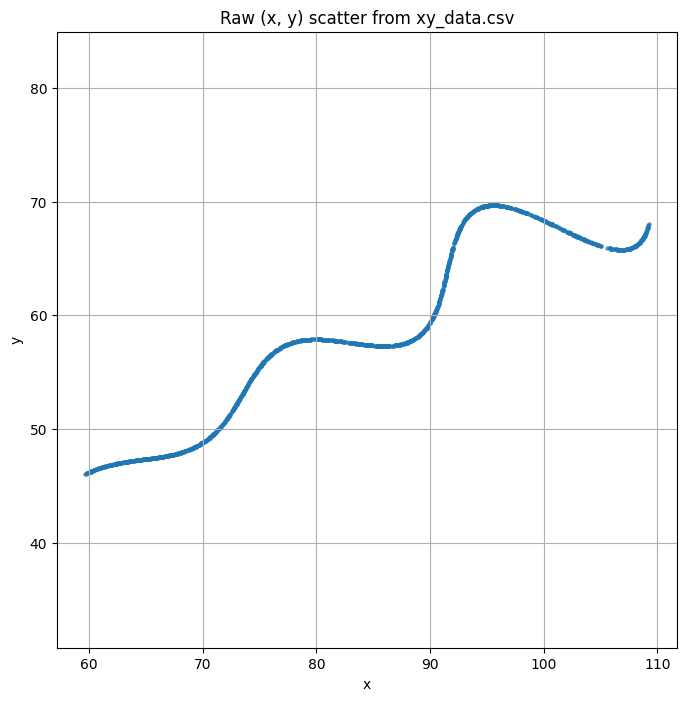

In [4]:
plt.figure(figsize=(8, 8))
plt.scatter(xs, ys, s=5, alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Raw (x, y) scatter from xy_data.csv')
plt.axis('equal')
plt.grid(True)
plt.show()

writing out the parametric equation exactly as given in the assignment, as a function of t and the three unknowns theta, M, X

In [5]:
def curve_xy(theta_deg, M, X, t):
    theta = np.radians(theta_deg)
    wiggle = np.exp(M * np.abs(t)) * np.sin(0.3 * t)
    x = t * np.cos(theta) - wiggle * np.sin(theta) + X
    y = 42 + t * np.sin(theta) + wiggle * np.cos(theta)
    return x, y

since i don't know which t value each point corresponds to, i can't fit t directly per point, instead i generate a dense version of the curve for a guess of theta/M/X and measure how far each real point is from its closest point on that curve, then sum it all up as one loss number

In [6]:
t_grid = np.linspace(6, 60, 4000)

def loss(params):
    theta, M, X = params
    cx, cy = curve_xy(theta, M, X, t_grid)

    dx = xs[:, None] - cx[None, :]
    dy = ys[:, None] - cy[None, :]
    d2 = dx**2 + dy**2
    min_d2 = np.min(d2, axis=1)
    return np.sum(min_d2)

using differential_evolution to search the whole allowed range for theta, M, X and find the combination that minimizes that loss, this avoids getting stuck in a wrong local answer

In [7]:
bounds = [(0, 50), (-0.05, 0.05), (0, 100)]

result = differential_evolution(
    loss, bounds, tol=1e-10, seed=0, maxiter=300, popsize=25, polish=True
)
print("Global search result:")
print("theta, M, X =", result.x)
print("loss =", result.fun)

Global search result:
theta, M, X = [2.99996119e+01 2.99997384e-02 5.49996146e+01]
loss = 0.032534525511452306


polishing the best guess from the global search with a local optimizer (nelder-mead) to squeeze out more precision

In [8]:
refined = minimize(loss, result.x, method='Nelder-Mead',
                    options={'xatol': 1e-10, 'fatol': 1e-12, 'maxiter': 20000})
theta_fit, M_fit, X_fit = refined.x
print("Refined theta, M, X =", refined.x)
print("Refined loss =", refined.fun)

Refined theta, M, X = [2.99996119e+01 2.99997385e-02 5.49996146e+01]
Refined loss = 0.032534525511366486


noticed the refined values were basically 30, 0.03, 55, checking if those exact clean numbers give roughly the same loss, which would confirm they're the real values and not just optimizer noise

In [9]:
clean_loss = loss([30.0, 0.03, 55.0])
print("Loss with clean values (30, 0.03, 55):", clean_loss)

Loss with clean values (30, 0.03, 55): 0.03257890709700412


plotting my fitted curve on top of the original data to visually confirm the fit actually matches

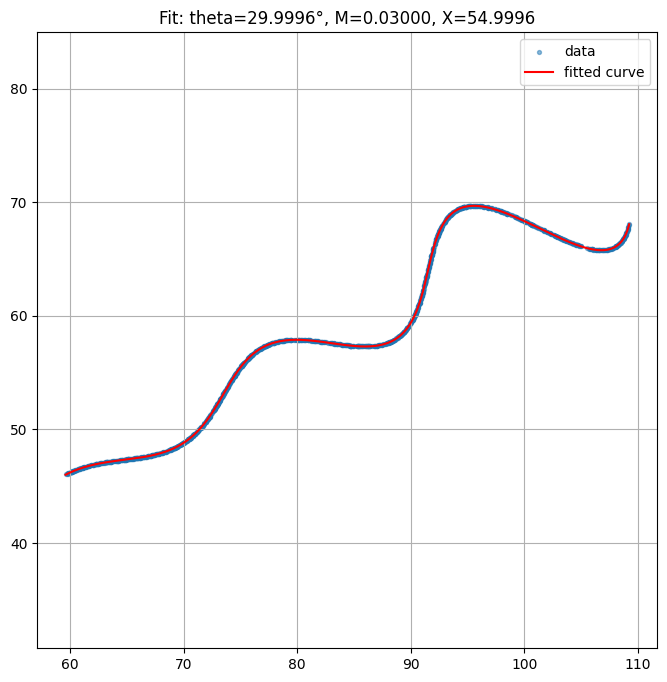

In [10]:
cx, cy = curve_xy(theta_fit, M_fit, X_fit, t_grid)

plt.figure(figsize=(8, 8))
plt.scatter(xs, ys, s=8, alpha=0.5, label='data')
plt.plot(cx, cy, color='red', linewidth=1.5, label='fitted curve')
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.title(f"Fit: theta={theta_fit:.4f}°, M={M_fit:.5f}, X={X_fit:.4f}")
plt.show()

generating the final answer in the exact latex/desmos format that is asked for, using theta=30, M=0.03, X=55

In [12]:
theta_deg = 30.0
theta_rad = np.radians(theta_deg)
M_final = 0.03
X_final = 55.0

answer_str = (
    f'\\left(t*\\cos({theta_rad:.6f})-e^{{{M_final}\\left|t\\right|}}'
    f'\\cdot\\sin(0.3t)\\sin({theta_rad:.6f})+{X_final},'
    f'42+t*\\sin({theta_rad:.6f})+e^{{{M_final}\\left|t\\right|}}'
    f'\\cdot\\sin(0.3t)\\cos({theta_rad:.6f})\\right)'
)
print(answer_str)

\left(t*\cos(0.523599)-e^{0.03\left|t\right|}\cdot\sin(0.3t)\sin(0.523599)+55.0,42+t*\sin(0.523599)+e^{0.03\left|t\right|}\cdot\sin(0.3t)\cos(0.523599)\right)
